<div style="font-size: 14pt;">Prof. Krzysztof Rybinski</div><br/><br/>
<div style="font-size: 22pt;"><b>Applied Machine Learning course</b></div><br/><br/>
<div style="font-size: 18pt;">Homework 4</div><br/>
<div style="font-size: 18pt;">RF, boosting and ROC</div><br/>

- Load KPI dataset used in Lab 3.0<br/>
- Split into train/test data (done)<br/>
- Train RF and one selected boosting ensemble models on train data set, use cross-validation<br/>
- Predict probabilities (predict_proba from Lab 3<br/>
- Use ROC curve to chose best threshold for each model<br/>
- Present the conclusions, show the best cross-validated model and best threshold<br/>
- Groups should make PowerPoint presentation, title + 6 slides max<br/>
- Hint: this homework combines Python code from Lab3 and Lab5<br/><br/>
                         
- <div style="font-size: 16pt;">Deadline is TUesday, 19 April 2022, 23:59</div>


In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import tree
from sklearn import set_config
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import statsmodels.api as sm
from sklearn.tree import plot_tree

#load and inspect KPI data
kpi = pd.read_csv("data/KPI_data_for_logit_model.csv")
kpi.columns

In [2]:
kpi = pd.read_csv("KPI_data_for_logit_model.csv") 

In [3]:
#select columns that we will use
kpi = kpi[['KPI_assessment_1', 'Number.of.questionnaires_1', 'Average_grade_1', \
           'NPS_1', 'Additional_achievement_1', 'X502010_1']]
kpi.columns 

Index(['KPI_assessment_1', 'Number.of.questionnaires_1', 'Average_grade_1',
       'NPS_1', 'Additional_achievement_1', 'X502010_1'],
      dtype='object')

In [4]:
#prepare train and test sets
y502010 = kpi[['X502010_1']]
X = kpi.drop(['X502010_1'], axis=1)
x_train, x_test, y_train, y_test = train_test_split(
    X, y502010, test_size=0.2, random_state=4, stratify=y502010)

#check proportions of 1s
y_train.mean(), y_test.mean()

(X502010_1    0.412338
 dtype: float64,
 X502010_1    0.415584
 dtype: float64)

In [5]:
#flatten vectors
y_train = y_train['X502010_1'].ravel()
y_test = y_test['X502010_1'].ravel()

RF Accuracy 0.7273


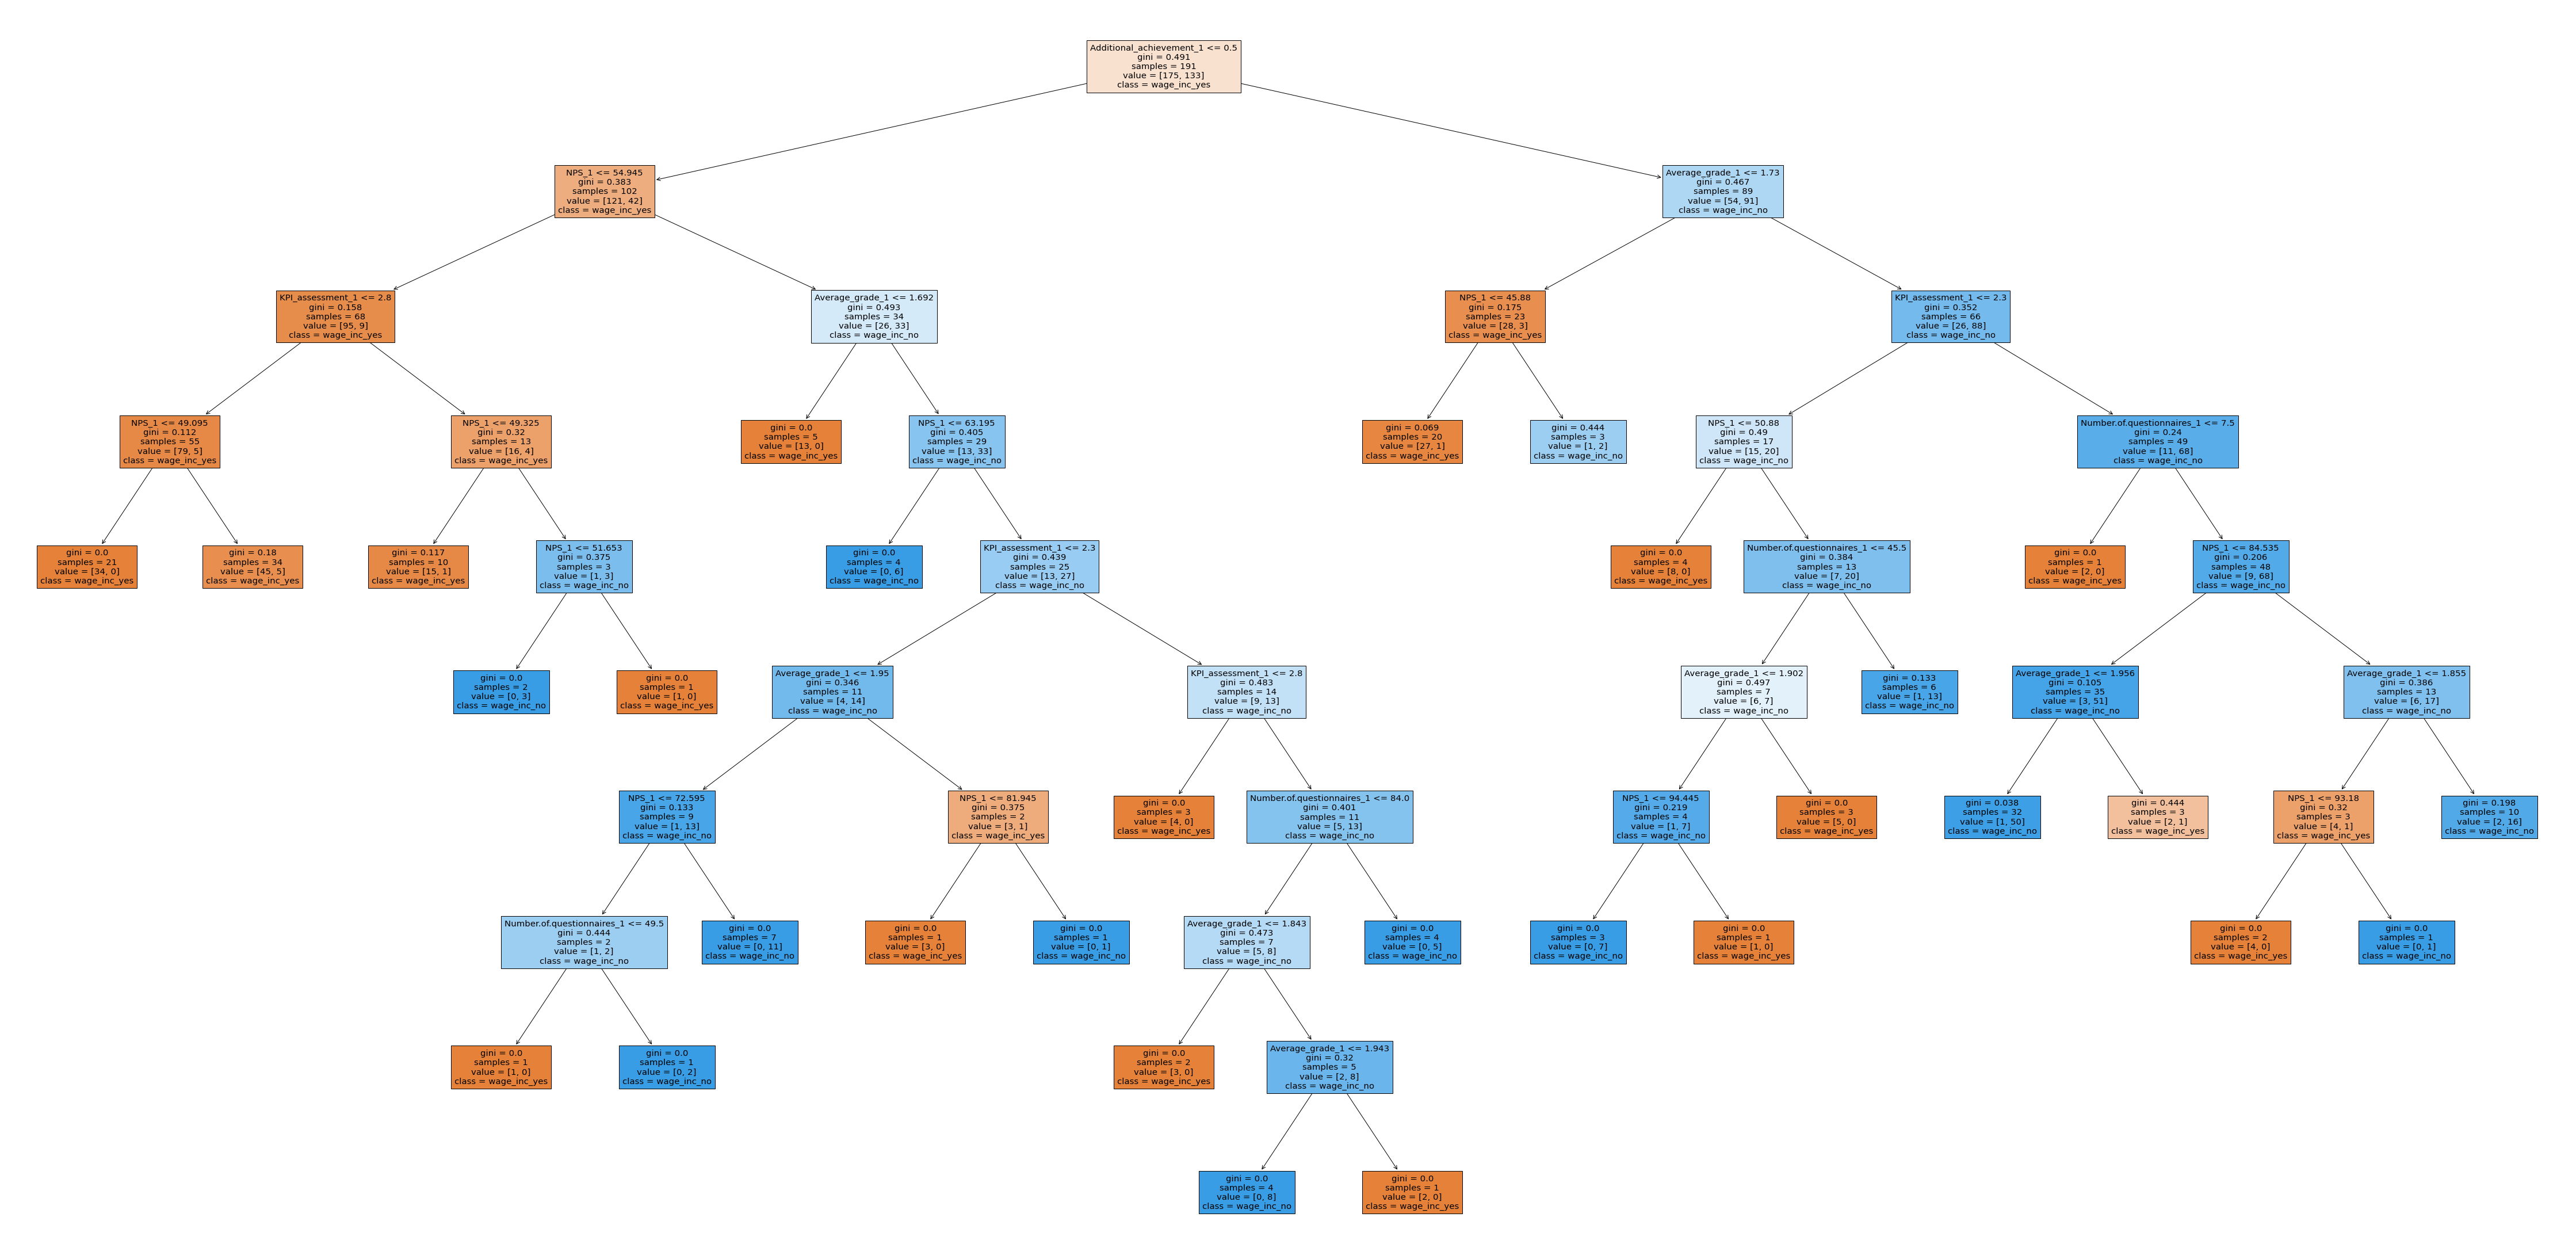

In [6]:
#use random forest to forecast, calculate test set accuracy
rf = RandomForestClassifier(n_estimators=200, max_leaf_nodes=30,random_state=200)
rf = rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
print("RF Accuracy", round(metrics.accuracy_score(y_test,y_pred),4))
plt.figure(figsize=(80,40))
tree.plot_tree(rf.estimators_[5], feature_names = X.columns,class_names=['wage_inc_yes', "wage_inc_no"],filled=True);

In [7]:
#cross-validate random forest, choose parameters and describe them in the presentations
rf = RandomForestClassifier()
params = {
    'max_depth': [80, 90, 100, 110],
    'n_estimators': [100, 200, 300, 1000],
    'random_state':[0,1,2,3],
    'ccp_alpha':[0.1,0.01,0.001]
         }
#check documentation
grid_search = GridSearchCV(estimator=rf,
                          param_grid=params,
                          cv = 5,
                          n_jobs=-1,
                          verbose=1,
                          scoring="accuracy")

grid_search.fit(x_train,y_train)
grid_search.best_score_
rf_best = grid_search.best_estimator_
rf_best

Fitting 5 folds for each of 192 candidates, totalling 960 fits


RandomForestClassifier(ccp_alpha=0.01, max_depth=80, random_state=3)

In [8]:
y_pred_rf = rf_best.predict(x_test)
print("CV rf accuracy:", round(metrics.accuracy_score(y_test,y_pred_rf),4))

CV rf accuracy: 0.7273


In [9]:
#calculate cross-validated model accuracy and calculate probabilities
#remember method ".predict_proba" returns two columns we use the second one
y_prob_rf = rf_best.predict_proba(x_test)
y_prob_rf = y_prob_rf[:,1]
y_prob_rf.shape,y_pred_rf.shape

((77,), (77,))

In [10]:
#get tpr, fpr and thresholds
fpr,tpr,thresholds = roc_curve(y_test,y_prob_rf)
str_thresholds = [str(round(x,2)) for x in thresholds]
print(fpr, '\n' , str_thresholds)

[0.         0.         0.         0.02222222 0.02222222 0.06666667
 0.06666667 0.08888889 0.08888889 0.13333333 0.13333333 0.2
 0.2        0.22222222 0.22222222 0.28888889 0.28888889 0.31111111
 0.31111111 0.35555556 0.35555556 0.4        0.4        0.44444444
 0.44444444 0.62222222 0.62222222 0.64444444 0.64444444 0.86666667
 0.95555556 1.        ] 
 ['1.84', '0.84', '0.8', '0.8', '0.79', '0.76', '0.75', '0.72', '0.65', '0.64', '0.64', '0.63', '0.63', '0.62', '0.62', '0.57', '0.52', '0.46', '0.42', '0.38', '0.31', '0.29', '0.28', '0.21', '0.17', '0.08', '0.07', '0.07', '0.06', '0.06', '0.05', '0.05']


In [11]:
#change every second threshold to dot
sel = list(range(len(str_thresholds))[::2])
for ind in sel:
    str_thresholds[ind] = '.'
print(str_thresholds)

['.', '0.84', '.', '0.8', '.', '0.76', '.', '0.72', '.', '0.64', '.', '0.63', '.', '0.62', '.', '0.57', '.', '0.46', '.', '0.38', '.', '0.29', '.', '0.21', '.', '0.08', '.', '0.07', '.', '0.06', '.', '0.05']


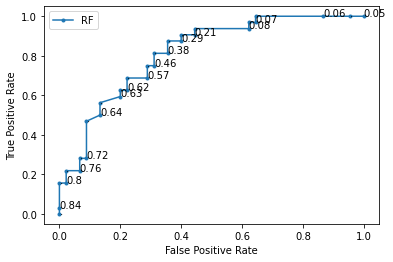

0.8149305555555555

In [12]:
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.', label='RF')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()

for i in range(len(thresholds)): 
    plt.text(fpr[i], tpr[i], str_thresholds[i], fontsize=10)

plt.show()
roc_auc_score(y_test, y_prob_rf)

In [13]:
#define function for checking different threshold values (see lab 3)

############################################################
def calculate_confusion_matrix(y_test, y_prob, threshold):
    y_pred_t = 1*(y_prob >= threshold)
    cfm = pd.crosstab(y_test, y_pred_t, rownames=['Actual'], colnames=['Predicted'])
    cfm = cfm / cfm.sum().sum()
    sns.heatmap(cfm, annot=True)
    accuracy = cfm.iloc[0,0] + cfm.iloc[1,1]
    print("`Accuracy =  {:6.4f}".format(accuracy))
    return cfm, accuracy
############################################################

`Accuracy =  0.7403


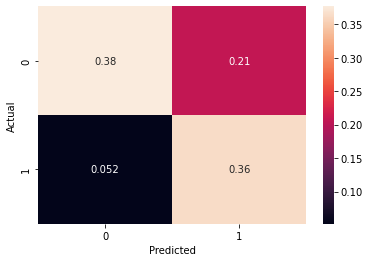

In [14]:
#try different thresholds, comment on changes in confussion matrix
cfm , accuracy = calculate_confusion_matrix(y_test, y_prob_rf, 0.3)

# AdaBoost Boosting Classifier

In [15]:
#AdaBoot
ab = AdaBoostClassifier(n_estimators = 200, random_state=123)
ab = ab.fit(x_train,y_train)
y_pred_ad = ab.predict(x_test)
print("AdaBoost accuracy:", round(metrics.accuracy_score(y_test,y_pred_ad),4))

AdaBoost accuracy: 0.6883


In [16]:
y_prob_ab_new = ab.predict_proba(x_test)
y_prob_ab_new = y_prob_ab_new[:,1]
y_prob_ab_new.shape,y_pred_ad.shape

((77,), (77,))

In [17]:
#get tpr, fpr and thresholds
fpr_ad,tpr_ad,thresholds_ad = roc_curve(y_test,y_prob_ab_new)
str_thresholds_ad = [str(round(x,2)) for x in thresholds_ad]
print(fpr_ad, '\n' , str_thresholds_ad)

[0.         0.         0.         0.04444444 0.04444444 0.08888889
 0.08888889 0.13333333 0.13333333 0.15555556 0.15555556 0.2
 0.2        0.22222222 0.28888889 0.28888889 0.31111111 0.31111111
 0.33333333 0.33333333 0.35555556 0.35555556 0.37777778 0.37777778
 0.6        0.62222222 0.62222222 0.75555556 0.75555556 1.        ] 
 ['1.51', '0.51', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.49', '0.49', '0.49', '0.49', '0.49', '0.45']


In [18]:
#change every second threshold to dot
sel_ad = list(range(len(str_thresholds_ad))[::2])
for ind in sel_ad:
    str_thresholds_ad[ind] = '.'
print(str_thresholds_ad)

['.', '0.51', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.5', '.', '0.49', '.', '0.49', '.', '0.45']


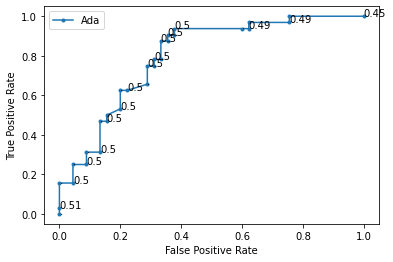

0.7982638888888889

In [19]:
# plot the roc curve for the model
plt.plot(fpr_ad, tpr_ad, marker='.', label='Ada')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()

for i in range(len(thresholds_ad)): 
    plt.text(fpr_ad[i], tpr_ad[i], str_thresholds_ad[i], fontsize=10)

plt.show()
roc_auc_score(y_test, y_prob_ab_new)

# Cross-Validation

In [20]:
adb = AdaBoostClassifier()
params = {
     'n_estimators': [50,100,200],
    'learning_rate': [0.01, 0.001,0.1],
    'random_state':[0,1,2,3]
         }
#check documentation
grid_search = GridSearchCV(estimator=adb,
                          param_grid=params,
                          cv = 5,
                          n_jobs=-1,
                          verbose=1,
                          scoring="accuracy")

grid_search.fit(x_train,y_train)
grid_search.best_score_
adb_best_n = grid_search.best_estimator_
adb_best_n

Fitting 5 folds for each of 36 candidates, totalling 180 fits


AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=0)

In [21]:
y_pred_adb = adb_best_n.predict(x_test)
print("CV AdaBoost accuracy:", round(metrics.accuracy_score(y_test,y_pred_adb),4))

CV AdaBoost accuracy: 0.7143


In [22]:
y_prob_adb = adb_best_n.predict_proba(x_test)
y_prob_adb = y_prob_adb[:,1]
y_prob_adb.shape,y_pred_adb.shape

((77,), (77,))

In [23]:
#get tpr, fpr and thresholds
fpr_ad,tpr_ad,thresholds_ad = roc_curve(y_test,y_prob_adb)
str_thresholds_ad = [str(round(x,2)) for x in thresholds_ad]
print(fpr_ad, '\n' , str_thresholds_ad)

[0.         0.         0.         0.02222222 0.02222222 0.04444444
 0.04444444 0.06666667 0.06666667 0.08888889 0.08888889 0.11111111
 0.11111111 0.13333333 0.13333333 0.24444444 0.26666667 0.26666667
 0.28888889 0.28888889 0.31111111 0.31111111 0.33333333 0.33333333
 0.4        0.4        0.42222222 0.64444444 0.64444444 0.68888889
 0.68888889 1.        ] 
 ['1.53', '0.53', '0.53', '0.53', '0.52', '0.52', '0.52', '0.52', '0.52', '0.51', '0.51', '0.51', '0.51', '0.51', '0.5', '0.5', '0.5', '0.5', '0.5', '0.49', '0.49', '0.49', '0.49', '0.48', '0.47', '0.47', '0.47', '0.47', '0.46', '0.46', '0.46', '0.4']


In [24]:
#change every second threshold to dot
sel_ad = list(range(len(str_thresholds_ad))[::2])
for ind in sel_ad:
    str_thresholds_ad[ind] = '.'
print(str_thresholds_ad)

['.', '0.53', '.', '0.53', '.', '0.52', '.', '0.52', '.', '0.51', '.', '0.51', '.', '0.51', '.', '0.5', '.', '0.5', '.', '0.49', '.', '0.49', '.', '0.48', '.', '0.47', '.', '0.47', '.', '0.46', '.', '0.4']


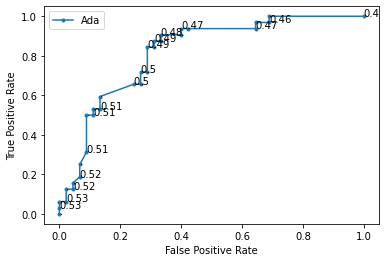

0.8190972222222221

In [25]:
# plot the roc curve for the model
plt.plot(fpr_ad, tpr_ad, marker='.', label='Ada')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()

for i in range(len(thresholds_ad)): 
    plt.text(fpr_ad[i], tpr_ad[i], str_thresholds_ad[i], fontsize=10)

plt.show()
roc_auc_score(y_test, y_prob_adb)

In [26]:
#define function for checking different threshold values (see lab 3)

############################################################
def calculate_confusion_matrix(y_test, y_prob_adb, threshold_ad):
    y_pred_t_ad = 1*(y_prob_adb >= threshold_ad)
    cfm_ad = pd.crosstab(y_test, y_pred_t_ad, rownames=['Actual'], colnames=['Predicted'])
    cfm_ad = cfm_ad / cfm_ad.sum().sum()
    sns.heatmap(cfm_ad, annot=True)
    accuracy_ad = cfm_ad.iloc[0,0] + cfm_ad.iloc[1,1]
    print("`Accuracy =  {:6.4f}".format(accuracy_ad))
    return cfm_ad, accuracy_ad
############################################################

`Accuracy =  0.7143


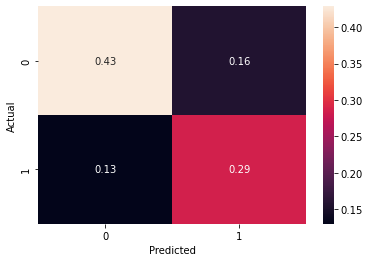

In [27]:
cfm_ad , accuracy_ad = calculate_confusion_matrix(y_test,y_prob_adb,0.5)

# Gradient Boost

In [28]:
gb = GradientBoostingClassifier(n_estimators=200, random_state=0)
gb = gb.fit(x_train,y_train)
y_pred_gb = gb.predict(x_test)
print("Gradient Boost Accuracy", round(metrics.accuracy_score(y_test,y_pred_gb),4))

Gradient Boost Accuracy 0.7013


# Cross Validation

In [29]:
gbs_n = GradientBoostingClassifier()
params = {
     'n_estimators': [50,100,200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3,4,5,80],
    'random_state':[0,1,2]
         }
#check documentation
grid_search = GridSearchCV(estimator=gbs_n,
                          param_grid=params,
                          cv = 5,
                          n_jobs=-1,
                          verbose=1,
                          scoring="accuracy")

grid_search.fit(x_train,y_train)
grid_search.best_score_
gbs_n_best_n = grid_search.best_estimator_
gbs_n_best_n

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GradientBoostingClassifier(learning_rate=0.01, n_estimators=200, random_state=0)

In [30]:
y_pred_gbs_n = gbs_n_best_n.predict(x_test)
print("CV Gradient Boost accuracy:", round(metrics.accuracy_score(y_test,y_pred_gbs_n),4))

CV Gradient Boost accuracy: 0.7403


In [31]:
#calculate cross-validated model accuracy and calculate probabilities
#remember method ".predict_proba" returns two columns we use the second one
y_prob_gbs_n = gbs_n_best_n.predict_proba(x_test)
y_prob_gbs_n = y_prob_gbs_n[:,1]
y_prob_gbs_n.shape,y_pred_gbs_n.shape

((77,), (77,))

In [32]:
#get tpr, fpr and thresholds
fpr_g,tpr_g,thresholds_g = roc_curve(y_test,y_prob_gbs_n)
str_thresholds_g = [str(round(x,2)) for x in thresholds_g]
print(fpr_g, '\n' , str_thresholds_g)

[0.         0.         0.         0.         0.         0.02222222
 0.02222222 0.06666667 0.06666667 0.08888889 0.08888889 0.11111111
 0.11111111 0.13333333 0.13333333 0.15555556 0.26666667 0.26666667
 0.28888889 0.28888889 0.31111111 0.31111111 0.35555556 0.35555556
 0.37777778 0.37777778 0.46666667 0.46666667 0.51111111 0.55555556
 0.6        0.82222222 0.84444444 0.91111111 0.95555556 1.        ] 
 ['1.85', '0.85', '0.78', '0.78', '0.73', '0.72', '0.71', '0.7', '0.7', '0.68', '0.66', '0.66', '0.64', '0.63', '0.6', '0.6', '0.59', '0.59', '0.58', '0.58', '0.55', '0.53', '0.41', '0.35', '0.31', '0.27', '0.19', '0.18', '0.13', '0.12', '0.11', '0.11', '0.11', '0.09', '0.07', '0.07']


In [33]:
#change every second threshold to dot
sel_g = list(range(len(str_thresholds_g))[::2])
for ind in sel_g:
    str_thresholds_g[ind] = '.'
print(str_thresholds_g)

['.', '0.85', '.', '0.78', '.', '0.72', '.', '0.7', '.', '0.68', '.', '0.66', '.', '0.63', '.', '0.6', '.', '0.59', '.', '0.58', '.', '0.53', '.', '0.35', '.', '0.27', '.', '0.18', '.', '0.12', '.', '0.11', '.', '0.09', '.', '0.07']


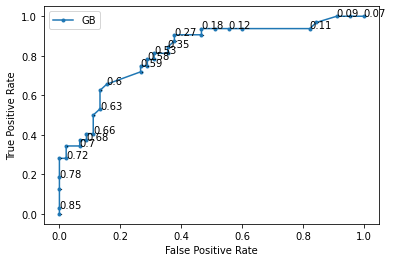

0.8197916666666668

In [34]:
# plot the roc curve for the model
plt.plot(fpr_g, tpr_g, marker='.', label='GB')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()

for i in range(len(thresholds_g)): 
    plt.text(fpr_g[i], tpr_g[i], str_thresholds_g[i], fontsize=10)

plt.show()
roc_auc_score(y_test, y_prob_gbs_n)

In [35]:
#define function for checking different threshold values (see lab 3)

############################################################
def calculate_confusion_matrix(y_test, y_prob_gbs_n, threshold_g):
    y_pred_t_g = 1*(y_prob_gbs_n >= threshold_g)
    cfm_g = pd.crosstab(y_test, y_pred_t_g, rownames=['Actual'], colnames=['Predicted'])
    cfm_g = cfm_g / cfm_g.sum().sum()
    sns.heatmap(cfm, annot=True)
    accuracy_g = cfm_g.iloc[0,0] + cfm_g.iloc[1,1]
    print("`Accuracy =  {:6.4f}".format(accuracy_g))
    return cfm_g, accuracy_g
############################################################

`Accuracy =  0.7662


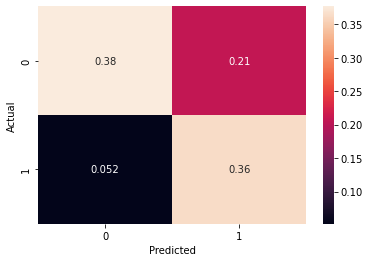

In [36]:
cfm_g , accuracy_g = calculate_confusion_matrix(y_test, y_prob_gbs_n, 0.6)

# XGBoost Boosting Classifier

In [37]:
xgb = XGBClassifier(n_estimators = 200, random_state=4567)
gbB = xgb.fit(x_train,y_train)
y_pred_gbB = gbB.predict(x_test)
print("XGBoost Accuracy", round(metrics.accuracy_score(y_test,y_pred_gbB),4))

C:\Users\abel\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[13:52:40] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
XGBoost Accuracy 0.7013


# Cross Validation

In [38]:
xgb_n = XGBClassifier()
params = {
     'n_estimators': [50,100,200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [1,2,3,4,5,6,80,90,100]
         }
#check documentation
grid_search = GridSearchCV(estimator=xgb_n,
                          param_grid=params,
                          cv = 5,
                          n_jobs=-1,
                          verbose=1,
                          scoring="accuracy")

grid_search.fit(x_train,y_train)
grid_search.best_score_
xgb_n_best_n = grid_search.best_estimator_
xgb_n_best_n

Fitting 5 folds for each of 54 candidates, totalling 270 fits


C:\Users\abel\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[13:53:02] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.01, max_delta_step=0,
              max_depth=3, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=200, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [39]:
y_pred_xgb_n = xgb_n_best_n.predict(x_test)
print("CV XGBoost Boost accuracy:", round(metrics.accuracy_score(y_test,y_pred_xgb_n),4))

CV XGBoost Boost accuracy: 0.7143


In [40]:
y_prob_xgb_n = xgb_n_best_n.predict_proba(x_test)
y_prob_xgb_n = y_prob_xgb_n[:,1]
y_prob_xgb_n.shape,y_pred_xgb_n.shape

((77,), (77,))

In [41]:
fpr_x,tpr_x,thresholds_x = roc_curve(y_test,y_prob_xgb_n)
str_thresholds_x = [str(round(x,2)) for x in thresholds_x]
print(fpr_x, '\n' , str_thresholds_x)

[0.         0.         0.         0.02222222 0.02222222 0.08888889
 0.08888889 0.2        0.22222222 0.22222222 0.24444444 0.24444444
 0.31111111 0.35555556 0.35555556 0.37777778 0.37777778 0.42222222
 0.42222222 0.46666667 0.51111111 0.55555556 0.6        0.82222222
 0.84444444 0.86666667 0.88888889 0.93333333 1.        ] 
 ['1.81', '0.81', '0.78', '0.75', '0.74', '0.71', '0.64', '0.63', '0.62', '0.61', '0.61', '0.59', '0.56', '0.56', '0.4', '0.34', '0.34', '0.27', '0.24', '0.21', '0.15', '0.14', '0.12', '0.12', '0.12', '0.11', '0.1', '0.09', '0.09']


In [42]:
#change every second threshold to dot
sel_x = list(range(len(str_thresholds_x))[::2])
for ind in sel_x:
    str_thresholds_x[ind] = '.'
print(str_thresholds_x)

['.', '0.81', '.', '0.75', '.', '0.71', '.', '0.63', '.', '0.61', '.', '0.59', '.', '0.56', '.', '0.34', '.', '0.27', '.', '0.21', '.', '0.14', '.', '0.12', '.', '0.11', '.', '0.09', '.']


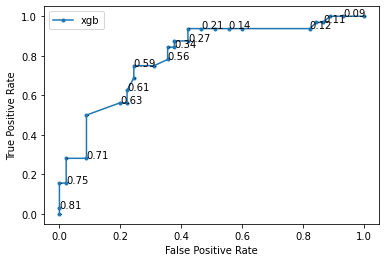

0.8006944444444444

In [43]:
# plot the roc curve for the model
plt.plot(fpr_x, tpr_x, marker='.', label='xgb')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()

for i in range(len(thresholds_x)): 
    plt.text(fpr_x[i], tpr_x[i], str_thresholds_x[i], fontsize=10)

plt.show()
roc_auc_score(y_test, y_prob_xgb_n)

In [44]:
#define function for checking different threshold values (see lab 3)

############################################################
def calculate_confusion_matrix(y_test, y_prob_xgb_n, threshold_x):
    y_pred_t_x = 1*(y_prob_xgb_n >= threshold_x)
    cfm_x = pd.crosstab(y_test, y_pred_t_x, rownames=['Actual'], colnames=['Predicted'])
    cfm_x = cfm_x / cfm_x.sum().sum()
    sns.heatmap(cfm_x, annot=True)
    accuracy_x = cfm_x.iloc[0,0] + cfm_x.iloc[1,1]
    print("`Accuracy =  {:6.4f}".format(accuracy_x))
    return cfm_x, accuracy_x
############################################################

`Accuracy =  0.7403


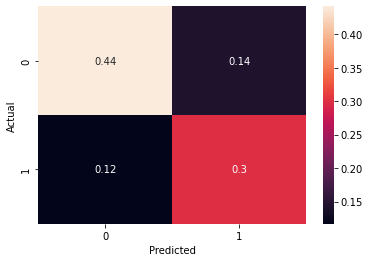

In [45]:
#try different thresholds, comment on changes in confussion matrix
cfm_x , accuracy_x = calculate_confusion_matrix(y_test,y_prob_xgb_n, 0.6)

# LGBM Boosting classifier

In [46]:
lgbm = lgb.LGBMClassifier()
lgbm = lgbm.fit(x_train,y_train)
y_pred_lg = lgbm.predict(x_test)
print("LGBM Accuracy", round(metrics.accuracy_score(y_test,y_pred_lg),4))

LGBM Accuracy 0.6883


# Cross Validation

In [47]:
lgbm_n = lgb.LGBMClassifier()
params = {
     'n_estimators': [50,100,200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [1,2,3,4,5,6]
         }
#check documentation
grid_search = GridSearchCV(estimator=lgbm_n,
                          param_grid=params,
                          cv = 5,
                          n_jobs=-1,
                          verbose=1,
                          scoring="accuracy")

grid_search.fit(x_train,y_train)
grid_search.best_score_
lgbm_n_best_n = grid_search.best_estimator_
lgbm_n_best_n

Fitting 5 folds for each of 36 candidates, totalling 180 fits


LGBMClassifier(max_depth=2, n_estimators=200)

In [48]:
y_pred_lgbm_n = lgbm_n_best_n.predict(x_test)
print("CV  LGBM classifier accuracy:", round(metrics.accuracy_score(y_test,y_pred_lgbm_n),4))

CV  LGBM classifier accuracy: 0.7403


In [49]:
y_prob_lgbm_n = lgbm_n_best_n.predict_proba(x_test)
y_prob_lgbm_n = y_prob_lgbm_n[:,1]
y_prob_lgbm_n.shape,y_pred_lgbm_n.shape

((77,), (77,))

In [50]:
fpr_l,tpr_l,thresholds_l = roc_curve(y_test,y_prob_lgbm_n)
str_thresholds_l = [str(round(x,2)) for x in thresholds_l]
print(fpr_l, '\n' , str_thresholds_l)

[0.         0.         0.         0.02222222 0.02222222 0.04444444
 0.04444444 0.06666667 0.06666667 0.08888889 0.08888889 0.13333333
 0.13333333 0.15555556 0.15555556 0.26666667 0.26666667 0.28888889
 0.28888889 0.31111111 0.31111111 0.33333333 0.33333333 0.4
 0.4        0.44444444 0.44444444 0.48888889 0.48888889 0.55555556
 0.77777778 0.82222222 0.91111111 0.91111111 0.95555556 1.        ] 
 ['1.97', '0.97', '0.91', '0.9', '0.88', '0.85', '0.83', '0.82', '0.82', '0.81', '0.78', '0.75', '0.68', '0.66', '0.62', '0.6', '0.57', '0.55', '0.49', '0.42', '0.4', '0.39', '0.37', '0.13', '0.13', '0.12', '0.12', '0.1', '0.09', '0.05', '0.04', '0.03', '0.01', '0.0', '0.0', '0.0']


In [51]:
#change every second threshold to dot
sel_l = list(range(len(str_thresholds_l))[::2])
for ind in sel_l:
    str_thresholds_l[ind] = '.'
print(str_thresholds_l)

['.', '0.97', '.', '0.9', '.', '0.85', '.', '0.82', '.', '0.81', '.', '0.75', '.', '0.66', '.', '0.6', '.', '0.55', '.', '0.42', '.', '0.39', '.', '0.13', '.', '0.12', '.', '0.1', '.', '0.05', '.', '0.03', '.', '0.0', '.', '0.0']


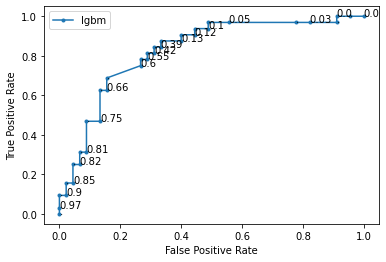

0.8249999999999998

In [52]:
# plot the roc curve for the model
plt.plot(fpr_l, tpr_l, marker='.', label='lgbm')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()

for i in range(len(thresholds_l)): 
    plt.text(fpr_l[i], tpr_l[i], str_thresholds_l[i], fontsize=10)


plt.savefig('plot_ROC_lgbm.pdf', dpi=300, bbox_inches='tight')
plt.show()
roc_auc_score(y_test, y_prob_lgbm_n)

In [53]:
#define function for checking different threshold values (see lab 3)

############################################################
def calculate_confusion_matrix(y_test, y_prob_lgbm_n, threshold_l):
    y_pred_t_l = 1*(y_prob_lgbm_n >= threshold_l)
    cfm_l = pd.crosstab(y_test, y_pred_t_l, rownames=['Actual'], colnames=['Predicted'])
    cfm_l = cfm_l / cfm_l.sum().sum()
    sns.heatmap(cfm_l, annot=True)
    accuracy_l = cfm_l.iloc[0,0] + cfm_l.iloc[1,1]
    print("`Accuracy =  {:6.4f}".format(accuracy_l))
    return cfm_l, accuracy_l
############################################################

`Accuracy =  0.7792


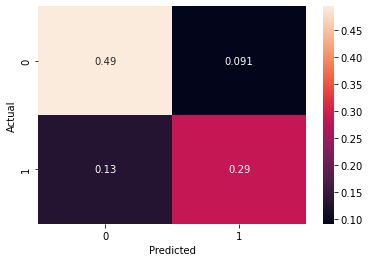

In [54]:
#try different thresholds, comment on changes in confussion matrix
cfm_l , accuracy_l = calculate_confusion_matrix(y_test,y_prob_lgbm_n, 0.6)

# CatBoost Boosting Classifier 

In [55]:
cb = CatBoostClassifier(iterations=200)
cb = cb.fit(x_train,y_train)
y_pred_cat = cb.predict(x_test)
print("CatBoost Accuracy", round(metrics.accuracy_score(y_test,y_pred_cat),4))

Learning rate set to 0.027258
0:	learn: 0.6783197	total: 153ms	remaining: 30.4s
1:	learn: 0.6642889	total: 154ms	remaining: 15.3s
2:	learn: 0.6478882	total: 156ms	remaining: 10.3s
3:	learn: 0.6298567	total: 158ms	remaining: 7.74s
4:	learn: 0.6182871	total: 160ms	remaining: 6.22s
5:	learn: 0.6088264	total: 161ms	remaining: 5.21s
6:	learn: 0.5949483	total: 164ms	remaining: 4.51s
7:	learn: 0.5825105	total: 166ms	remaining: 3.99s
8:	learn: 0.5724199	total: 168ms	remaining: 3.57s
9:	learn: 0.5621368	total: 170ms	remaining: 3.23s
10:	learn: 0.5526394	total: 171ms	remaining: 2.94s
11:	learn: 0.5405386	total: 173ms	remaining: 2.71s
12:	learn: 0.5330583	total: 175ms	remaining: 2.51s
13:	learn: 0.5213454	total: 177ms	remaining: 2.35s
14:	learn: 0.5168565	total: 179ms	remaining: 2.2s
15:	learn: 0.5090727	total: 181ms	remaining: 2.08s
16:	learn: 0.4995169	total: 183ms	remaining: 1.96s
17:	learn: 0.4916620	total: 184ms	remaining: 1.86s
18:	learn: 0.4875708	total: 185ms	remaining: 1.76s
19:	learn: 0

# Cross Validation 

In [56]:
catb_n = CatBoostClassifier()
params = {
     
    'learning_rate': [0.01, 0.001,0.1],
    'min_data_in_leaf': [1,2,3,4,5,6]
         }
#check documentation
grid_search = GridSearchCV(estimator=catb_n,
                          param_grid=params,
                          cv = 5,
                          n_jobs=-1,
                          verbose=1,
                          scoring="accuracy")

grid_search.fit(x_train,y_train)
grid_search.best_score_
catb_n_best_n = grid_search.best_estimator_
catb_n_best_n

Fitting 5 folds for each of 18 candidates, totalling 90 fits
0:	learn: 0.6876429	total: 2.38ms	remaining: 2.38s
1:	learn: 0.6818223	total: 4.74ms	remaining: 2.36s
2:	learn: 0.6753746	total: 6.61ms	remaining: 2.19s
3:	learn: 0.6680492	total: 10.8ms	remaining: 2.68s
4:	learn: 0.6630645	total: 17ms	remaining: 3.38s
5:	learn: 0.6588607	total: 20ms	remaining: 3.32s
6:	learn: 0.6521686	total: 23.4ms	remaining: 3.32s
7:	learn: 0.6463763	total: 44.4ms	remaining: 5.5s
8:	learn: 0.6418316	total: 54.6ms	remaining: 6.01s
9:	learn: 0.6356445	total: 57.8ms	remaining: 5.73s
10:	learn: 0.6289022	total: 61.8ms	remaining: 5.55s
11:	learn: 0.6228404	total: 64.2ms	remaining: 5.28s
12:	learn: 0.6187056	total: 65.8ms	remaining: 5s
13:	learn: 0.6132502	total: 68ms	remaining: 4.79s
14:	learn: 0.6094781	total: 70.4ms	remaining: 4.62s
15:	learn: 0.6051117	total: 72.7ms	remaining: 4.47s
16:	learn: 0.5993131	total: 75ms	remaining: 4.33s
17:	learn: 0.5965794	total: 76.1ms	remaining: 4.15s
18:	learn: 0.5925337	tota

211:	learn: 0.3169383	total: 485ms	remaining: 1.8s
212:	learn: 0.3165398	total: 487ms	remaining: 1.8s
213:	learn: 0.3160282	total: 489ms	remaining: 1.79s
214:	learn: 0.3155269	total: 491ms	remaining: 1.79s
215:	learn: 0.3152316	total: 493ms	remaining: 1.79s
216:	learn: 0.3148121	total: 495ms	remaining: 1.78s
217:	learn: 0.3142797	total: 497ms	remaining: 1.78s
218:	learn: 0.3137442	total: 499ms	remaining: 1.78s
219:	learn: 0.3129997	total: 502ms	remaining: 1.78s
220:	learn: 0.3123244	total: 504ms	remaining: 1.77s
221:	learn: 0.3116187	total: 506ms	remaining: 1.77s
222:	learn: 0.3108583	total: 508ms	remaining: 1.77s
223:	learn: 0.3105616	total: 510ms	remaining: 1.77s
224:	learn: 0.3099722	total: 512ms	remaining: 1.76s
225:	learn: 0.3094531	total: 513ms	remaining: 1.76s
226:	learn: 0.3088794	total: 515ms	remaining: 1.75s
227:	learn: 0.3081092	total: 517ms	remaining: 1.75s
228:	learn: 0.3076722	total: 519ms	remaining: 1.75s
229:	learn: 0.3073513	total: 520ms	remaining: 1.74s
230:	learn: 0.

391:	learn: 0.2448580	total: 820ms	remaining: 1.27s
392:	learn: 0.2448023	total: 821ms	remaining: 1.27s
393:	learn: 0.2442848	total: 822ms	remaining: 1.26s
394:	learn: 0.2440000	total: 824ms	remaining: 1.26s
395:	learn: 0.2438242	total: 826ms	remaining: 1.26s
396:	learn: 0.2435835	total: 827ms	remaining: 1.26s
397:	learn: 0.2435523	total: 828ms	remaining: 1.25s
398:	learn: 0.2432771	total: 829ms	remaining: 1.25s
399:	learn: 0.2426952	total: 831ms	remaining: 1.25s
400:	learn: 0.2423353	total: 833ms	remaining: 1.24s
401:	learn: 0.2419584	total: 835ms	remaining: 1.24s
402:	learn: 0.2416123	total: 837ms	remaining: 1.24s
403:	learn: 0.2413730	total: 839ms	remaining: 1.24s
404:	learn: 0.2410870	total: 841ms	remaining: 1.23s
405:	learn: 0.2407714	total: 842ms	remaining: 1.23s
406:	learn: 0.2404584	total: 844ms	remaining: 1.23s
407:	learn: 0.2401344	total: 845ms	remaining: 1.23s
408:	learn: 0.2396640	total: 847ms	remaining: 1.22s
409:	learn: 0.2395739	total: 848ms	remaining: 1.22s
410:	learn: 

571:	learn: 0.1958465	total: 1.15s	remaining: 857ms
572:	learn: 0.1956202	total: 1.15s	remaining: 855ms
573:	learn: 0.1952858	total: 1.15s	remaining: 853ms
574:	learn: 0.1950256	total: 1.15s	remaining: 851ms
575:	learn: 0.1948221	total: 1.15s	remaining: 849ms
576:	learn: 0.1945878	total: 1.15s	remaining: 847ms
577:	learn: 0.1943538	total: 1.16s	remaining: 844ms
578:	learn: 0.1941907	total: 1.16s	remaining: 842ms
579:	learn: 0.1939274	total: 1.16s	remaining: 840ms
580:	learn: 0.1936796	total: 1.16s	remaining: 837ms
581:	learn: 0.1935050	total: 1.16s	remaining: 835ms
582:	learn: 0.1933608	total: 1.16s	remaining: 833ms
583:	learn: 0.1930566	total: 1.17s	remaining: 830ms
584:	learn: 0.1929478	total: 1.17s	remaining: 828ms
585:	learn: 0.1927176	total: 1.17s	remaining: 826ms
586:	learn: 0.1924534	total: 1.17s	remaining: 824ms
587:	learn: 0.1922685	total: 1.17s	remaining: 822ms
588:	learn: 0.1921845	total: 1.17s	remaining: 819ms
589:	learn: 0.1920009	total: 1.18s	remaining: 817ms
590:	learn: 

745:	learn: 0.1599652	total: 1.63s	remaining: 555ms
746:	learn: 0.1597170	total: 1.63s	remaining: 553ms
747:	learn: 0.1595760	total: 1.63s	remaining: 550ms
748:	learn: 0.1594024	total: 1.64s	remaining: 548ms
749:	learn: 0.1593082	total: 1.64s	remaining: 546ms
750:	learn: 0.1590969	total: 1.64s	remaining: 544ms
751:	learn: 0.1589400	total: 1.64s	remaining: 542ms
752:	learn: 0.1587231	total: 1.64s	remaining: 540ms
753:	learn: 0.1585456	total: 1.65s	remaining: 537ms
754:	learn: 0.1582542	total: 1.65s	remaining: 535ms
755:	learn: 0.1580408	total: 1.65s	remaining: 533ms
756:	learn: 0.1579086	total: 1.65s	remaining: 531ms
757:	learn: 0.1576791	total: 1.66s	remaining: 529ms
758:	learn: 0.1574220	total: 1.66s	remaining: 527ms
759:	learn: 0.1573425	total: 1.66s	remaining: 525ms
760:	learn: 0.1571190	total: 1.66s	remaining: 523ms
761:	learn: 0.1570140	total: 1.67s	remaining: 521ms
762:	learn: 0.1568817	total: 1.67s	remaining: 518ms
763:	learn: 0.1567479	total: 1.67s	remaining: 516ms
764:	learn: 

980:	learn: 0.1289628	total: 2.12s	remaining: 41.1ms
981:	learn: 0.1288013	total: 2.13s	remaining: 39ms
982:	learn: 0.1286335	total: 2.13s	remaining: 36.8ms
983:	learn: 0.1285988	total: 2.13s	remaining: 34.6ms
984:	learn: 0.1284738	total: 2.13s	remaining: 32.4ms
985:	learn: 0.1283158	total: 2.13s	remaining: 30.3ms
986:	learn: 0.1281865	total: 2.13s	remaining: 28.1ms
987:	learn: 0.1281214	total: 2.14s	remaining: 25.9ms
988:	learn: 0.1280611	total: 2.14s	remaining: 23.8ms
989:	learn: 0.1280027	total: 2.14s	remaining: 21.6ms
990:	learn: 0.1279274	total: 2.14s	remaining: 19.5ms
991:	learn: 0.1278777	total: 2.14s	remaining: 17.3ms
992:	learn: 0.1278076	total: 2.15s	remaining: 15.1ms
993:	learn: 0.1277565	total: 2.15s	remaining: 13ms
994:	learn: 0.1277119	total: 2.15s	remaining: 10.8ms
995:	learn: 0.1275818	total: 2.15s	remaining: 8.65ms
996:	learn: 0.1275069	total: 2.15s	remaining: 6.49ms
997:	learn: 0.1274443	total: 2.16s	remaining: 4.32ms
998:	learn: 0.1273042	total: 2.16s	remaining: 2.16

In [57]:
y_pred_catb_n = catb_n_best_n.predict(x_test)
print("CV  CatBoost accuracy:", round(metrics.accuracy_score(y_test,y_pred_catb_n),4))

CV  CatBoost accuracy: 0.7403


In [58]:
y_prob_catb = catb_n_best_n.predict_proba(x_test)
y_prob_catb = y_prob_catb[:,1]
y_prob_catb.shape,y_pred_catb_n.shape

((77,), (77,))

In [59]:
fpr_c,tpr_c,thresholds_c = roc_curve(y_test,y_prob_catb)
str_thresholds_c = [str(round(x,2)) for x in thresholds_c]
print(fpr_c, '\n' , str_thresholds_c)

[0.         0.         0.         0.02222222 0.02222222 0.06666667
 0.11111111 0.11111111 0.17777778 0.17777778 0.2        0.2
 0.26666667 0.28888889 0.28888889 0.33333333 0.33333333 0.42222222
 0.42222222 0.48888889 0.48888889 0.55555556 0.55555556 0.6
 0.82222222 0.86666667 0.86666667 1.        ] 
 ['1.99', '0.99', '0.92', '0.91', '0.9', '0.89', '0.82', '0.81', '0.77', '0.73', '0.71', '0.69', '0.69', '0.68', '0.52', '0.39', '0.3', '0.21', '0.21', '0.11', '0.06', '0.03', '0.03', '0.02', '0.02', '0.01', '0.01', '0.0']


In [60]:
#change every second threshold to dot
sel_c = list(range(len(str_thresholds_c))[::2])
for ind in sel_c:
    str_thresholds_c[ind] = '.'
print(str_thresholds_c)

['.', '0.99', '.', '0.91', '.', '0.89', '.', '0.81', '.', '0.73', '.', '0.69', '.', '0.68', '.', '0.39', '.', '0.21', '.', '0.11', '.', '0.03', '.', '0.02', '.', '0.01', '.', '0.0']


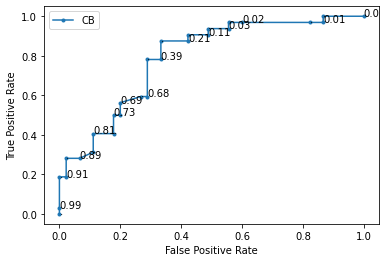

0.7899305555555556

In [61]:
# plot the roc curve for the model
plt.plot(fpr_c, tpr_c, marker='.', label='CB')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()

for i in range(len(thresholds_c)): 
    plt.text(fpr_c[i], tpr_c[i], str_thresholds_c[i], fontsize=10)

plt.show()
roc_auc_score(y_test, y_prob_catb)

In [62]:
#define function for checking different threshold values (see lab 3)

############################################################
def calculate_confusion_matrix(y_test, y_prob_catb, threshold_c):
    y_pred_t_c = 1*(y_prob_catb >= threshold_c)
    cfm_c = pd.crosstab(y_test, y_pred_t_c, rownames=['Actual'], colnames=['Predicted'])
    cfm_c = cfm_c / cfm_c.sum().sum()
    sns.heatmap(cfm_c, annot=True)
    accuracy_c = cfm_c.iloc[0,0] + cfm_c.iloc[1,1]
    print("`Accuracy =  {:6.4f}".format(accuracy_c))
    return cfm_c, accuracy_c
############################################################

`Accuracy =  0.7403


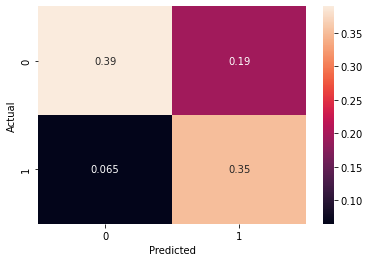

In [63]:
#try different thresholds, comment on changes in confussion matrix
cfm_c , accuracy_c = calculate_confusion_matrix(y_test,y_prob_catb, 0.3)

# Visualization information For LGBM and AdaBoost Boosting Classifiers 

In [64]:
data = {
    'AD':[0.6883,0.7143,0.7143],
    'LG':[0.6889,0.7403,0.7792]
}

In [65]:
data = pd.DataFrame(data);
data.head()
data.set_index([['Before_CV','After_CV','CV_CFM']], inplace=True)
data.rename(columns = {'AD':'AdaBoost','LG':'LGBM'}, inplace = True)

In [66]:
data

,AdaBoost,LGBM
Before_CV,0.6883,0.6889
After_CV,0.7143,0.7403
CV_CFM,0.7143,0.7792


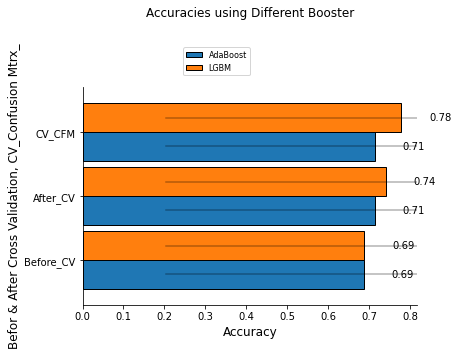

In [67]:
plots = data.plot.barh(width=0.9, lw = 1,edgecolor="black")
rects = plots.patches
for rect in rects:
    x_value = rect.get_width()
    y_value = rect.get_y() + rect.get_height() / 2 
    plt.axhline(y = y_value,xmin = 0.25, xmax = 0.999, color = 'k', linestyle = '-',alpha=0.3)
  
    label = '{:,.2f}'.format(x_value)
    space = 50
    ha = 'right'
    plt.annotate(label,(x_value, y_value),xytext=(space, 0),         
        textcoords='offset points', 
        va='center',                
        ha=ha,                    
        color = 'black', fontsize=10)            
plt.legend(bbox_to_anchor=(0.4,1.12),loc="center",fontsize=8)
plt.title("Accuracies using Different Booster",y=1.39, pad=-14)
ax=plt.gca()
ax.spines[['top','right']].set_visible(False)
plt.savefig('filename1.png', dpi=300)
plt.xlabel("Accuracy")
plt.ylabel("Befor & After Cross Validation, CV_Confusion Mtrx_")
axes = plt.gca()
axes.xaxis.label.set_size(12)
axes.yaxis.label.set_size(12)
#plt.savefig("100.png" , dpi = 100)
#plt.savefig("300.png" , dpi = 300)
plt.savefig('plot.pdf', dpi=300, bbox_inches='tight')
plt.show()